In [1]:
import pandas as pd
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_seq_items', None)

### EDA

In [2]:
child_df = pd.read_excel('data/CBDI3 All Evals for NSS.xlsx')
child_df.columns

Index(['Child ID', 'Gender', 'Date of Birth', 'Location - Sub Level 1',
       'contract number', 'Program Label', 'Adaptive Sum of Scaled Scores',
       'Adaptive Developmental Quotient', 'Adaptive Percentile Rank',
       'Adaptive 95% Confidence Interval', 'Adaptive RDI', 'Adaptive Z-Score',
       'Adaptive T-Score', 'Adaptive NCE',
       'Social-Emotional Sum of Scaled Scores',
       'Social-Emotional Developmental Quotient',
       'Social-Emotional Percentile Rank',
       'Social-Emotional 95% Confidence Interval', 'Social-Emotional RDI',
       'Social-Emotional Z-Score', 'Social-Emotional T-Score',
       'Social-Emotional NCE', 'Communication Sum of Scaled Scores',
       'Communication Developmental Quotient', 'Communication Percentile Rank',
       'Communication 95% Confidence Interval', 'Communication RDI',
       'Communication Z-Score', 'Communication T-Score', 'Communication NCE',
       'Motor Sum of Scaled Scores', 'Motor Developmental Quotient',
       'Motor Pe

In [3]:
child_df = (
    child_df.rename(columns={
        'Child ID': 'child_id',
        'Gender': 'gender',
        'Date of Birth': 'DOB',
        'Location - Sub Level 1': 'location_sublvl1',
        'contract number': 'contract_no',
        'Program Label': 'program_lbl'
    }).drop(columns=['Code 1', 'Code 2', 'Code 3','Code 4', 'Code 5', 'Code 6', 'Code 7', 'Code 8', 'Code 9', 'Code 10'])
)

child_df = child_df.drop_duplicates()

In [4]:
domains = {
    'Adaptive': ['Self Care', 'Personal Responsibility'],
    'Social-Emotional': ['Adult Interaction', 'Peer Interaction', 'Self Concept / Social Role'],
    'Communication': ['Receptive Communication', 'Expressive Communication'],
    'Motor': ['Gross Motor', 'Fine Motor', 'Perceptual Motor'],
    'Cognitive': ['Attention and Memory', 'Reasoning / Academic Skills', 'Perception and Concepts']
}

In [5]:
for dom in domains.keys():
    # Cleaning Domain Percentile Rank
    child_df[f'{dom} Percentile Rank'] = child_df[f'{dom} Percentile Rank'].replace('<0.1', 0.01)
    child_df[f'{dom} Percentile Rank'] = child_df[f'{dom} Percentile Rank'].replace('>99.9', 99.99)

    for s_dom in domains[dom]:
        dom_str = dom.replace('-', ' ')
        # Cleaning Sub-Domain Percentile Rank
        child_df[f'{dom_str}-{s_dom} PR'] = child_df[f'{dom_str}-{s_dom} PR'].replace('<1', 0.1)
        child_df[f'{dom_str}-{s_dom} PR'] = child_df[f'{dom_str}-{s_dom} PR'].replace('>99', 99.9)

        # Create Sub-Domain Ages
        child_df[f'{dom_str}-{s_dom} Testing Age'] = child_df[f'{dom_str}-{s_dom} Date of Testing'] - child_df['DOB']
    
    # Fixing incorrect RDI values
    child_df[f'{dom} RDI'] = child_df[f'{dom} RDI'].astype(str).str.replace(r'\d{4}-(\d{2})-.*',r'\1',regex=True)
    child_df[f'{dom} RDI'] = child_df[f'{dom} RDI'].str.replace(r'^(\d{2})$',r'\1/90',regex=True)

/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_69896/561663309.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  child_df[f'{dom} Percentile Rank'] = child_df[f'{dom} Percentile Rank'].replace('<0.1', 0.01)
/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_69896/561663309.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  child_df[f'{dom_str}-{s_dom} PR'] = child_df[f'{dom_str}-{s_dom} PR'].replace('>99', 99.9)
/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_69896/561663309.py:10: FutureWarning:

### 1. In which domains (and sub-domains) are children performing highest and lowest?

In [6]:
import re
import seaborn as sns
import matplotlib.pyplot as plt

columns = child_df.columns.tolist()

In [7]:
domPR_col = [col for col in columns if re.match(r'.*Percentile Rank', col)]
domPR_col.remove('BDI-3 Total Percentile Rank')
domPR_df = child_df[domPR_col]

domPR_df.columns = ['Adaptive', 'Social-Emotional', 'Communication', 'Motor', 'Cognitive']

In [8]:
domPR_df

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
0,16.0,96.0,27.0,21.0,50.0
1,21.0,61.0,42.0,55.0,50.0
2,25.0,27.0,12.0,73.0,13.0
3,84.0,58.0,21.0,27.0,81.0
4,5.0,4.0,2.0,4.0,42.0
...,...,...,...,...,...
23942,84.0,84.0,79.0,88.0,81.0
23943,84.0,86.0,79.0,87.0,93.0
23944,58.0,55.0,0.1,61.0,45.0
23945,21.0,25.0,5.0,50.0,21.0


In [9]:
colormap = {
    'Adaptive': '#4c72b0',
    'Social-Emotional': '#dd8452',
    'Communication': '#55a868',
    'Motor': '#c44e52',
    'Cognitive': '#8172b3'
}

<Axes: >

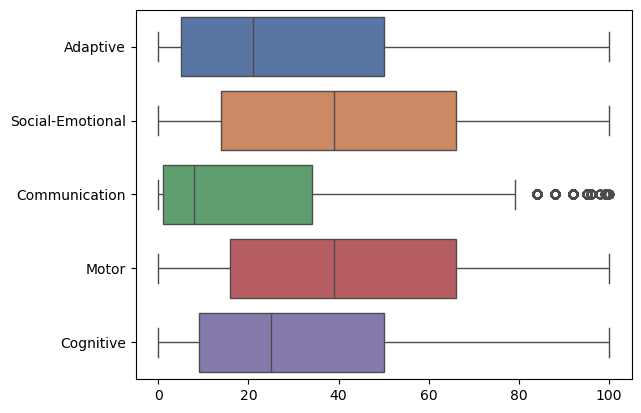

In [10]:
sns.boxplot(domPR_df, orient='h', palette=colormap)

In [11]:
subdomPR_col = [col for col in columns if re.match(r'.*PR', col)]
subdomPR_df = child_df[subdomPR_col]

subdomPR_df.columns = [re.sub(r'\sPR$', '', col) for col in subdomPR_col]

In [12]:
subcolormap = {}
for col in subdomPR_df.columns:
    for dom, color in colormap.items():
        dom_str = dom.replace('-', ' ')
        if re.match(rf'^{dom_str}.*', col):
            subcolormap[col] = color

In [13]:
subcolormap

{'Adaptive-Self Care': '#4c72b0',
 'Adaptive-Personal Responsibility': '#4c72b0',
 'Social Emotional-Adult Interaction': '#dd8452',
 'Social Emotional-Peer Interaction': '#dd8452',
 'Social Emotional-Self Concept / Social Role': '#dd8452',
 'Communication-Receptive Communication': '#55a868',
 'Communication-Expressive Communication': '#55a868',
 'Motor-Gross Motor': '#c44e52',
 'Motor-Fine Motor': '#c44e52',
 'Motor-Perceptual Motor': '#c44e52',
 'Cognitive-Attention and Memory': '#8172b3',
 'Cognitive-Reasoning / Academic Skills': '#8172b3',
 'Cognitive-Perception and Concepts': '#8172b3'}

<Axes: >

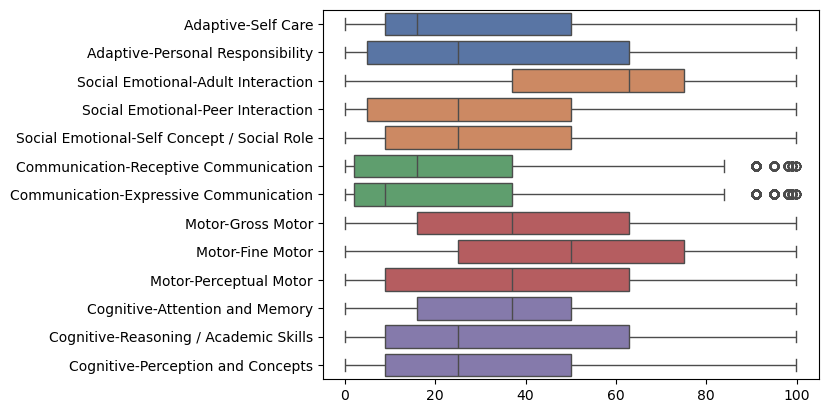

In [14]:
sns.boxplot(subdomPR_df, orient='h',palette=subcolormap)

### Eligible vs Reeval

In [15]:
child_elig_df = child_df.loc[child_df['program_lbl'] == 'BDI-3 Eligibility Evaluation']
child_reeval_df = child_df.loc[child_df['program_lbl'] != 'BDI-3 Eligibility Evaluation']

In [16]:
child_elig_df = child_elig_df.loc[child_elig_df['child_id'].isin(child_reeval_df['child_id'])]

elig_domPR_df = child_elig_df[domPR_col]
reeval_domPR_df = child_reeval_df[domPR_col]

In [17]:
elig_domPR_df.columns = ['Adaptive', 'Social-Emotional', 'Communication', 'Motor', 'Cognitive', 'BDI-3 Total']
reeval_domPR_df.columns = ['Adaptive', 'Social-Emotional', 'Communication', 'Motor', 'Cognitive', 'BDI-3 Total']

ValueError: Length mismatch: Expected axis has 5 elements, new values have 6 elements

In [ ]:
sns.boxplot(elig_domPR_df, orient='h', palette=colormap)

In [ ]:
sns.boxplot(reeval_domPR_df, orient='h', palette=colormap)

**Follow up notes:**
- Grouping the dataframe by child ID to see how the summary statistics change

### 2. What is the pattern of children's scores? Do individual children tend to perform similarly across all domains or are there differences from domain to domain? Are these patterns similar for all children?

In [84]:
rank_df = pd.DataFrame()
rank_df[[dom + '_Rank' for dom in domains.keys()]] = child_df[domPR_col].rank(axis=1,ascending=False,method='min').astype('Int64')

In [86]:
rank_df

,Adaptive_Rank,Social-Emotional_Rank,Communication_Rank,Motor_Rank,Cognitive_Rank
0,5,1,3,4,2
1,5,1,4,2,3
2,3,2,5,1,4
3,1,3,5,4,2
4,2,3,5,3,1
...,...,...,...,...,...
23942,2,2,5,1,4
23943,4,3,5,2,1
23944,2,3,5,1,4
23945,3,2,5,1,3


<Axes: xlabel='Adaptive_Rank', ylabel='Count'>

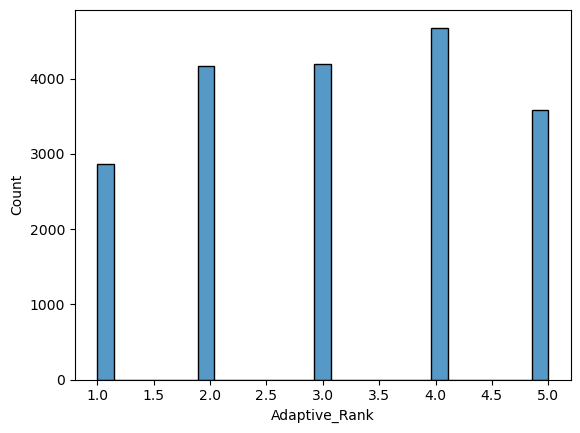

In [87]:
sns.histplot(rank_df,x='Adaptive_Rank')

<Axes: xlabel='Social-Emotional_Rank', ylabel='Count'>

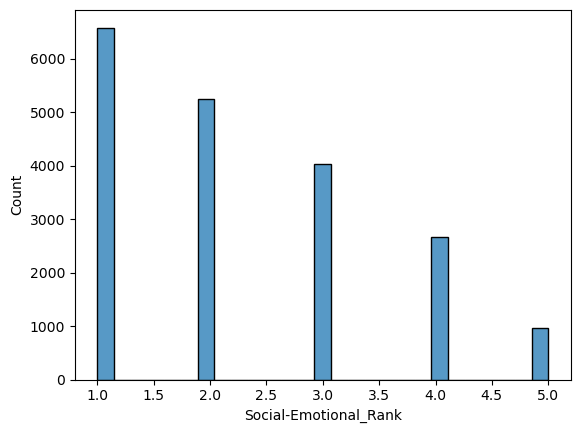

In [88]:
sns.histplot(rank_df,x='Social-Emotional_Rank')

<Axes: xlabel='Communication_Rank', ylabel='Count'>

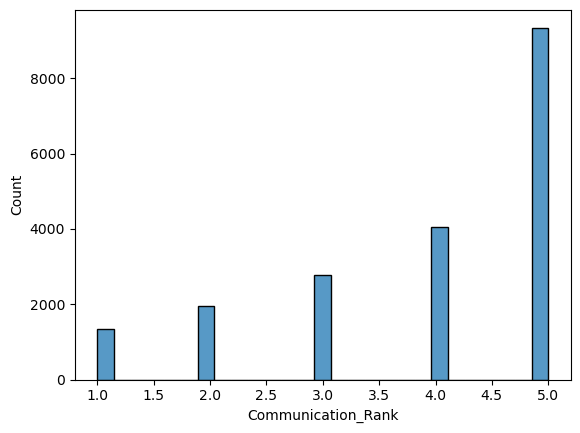

In [89]:
sns.histplot(rank_df,x='Communication_Rank')

<Axes: xlabel='Motor_Rank', ylabel='Count'>

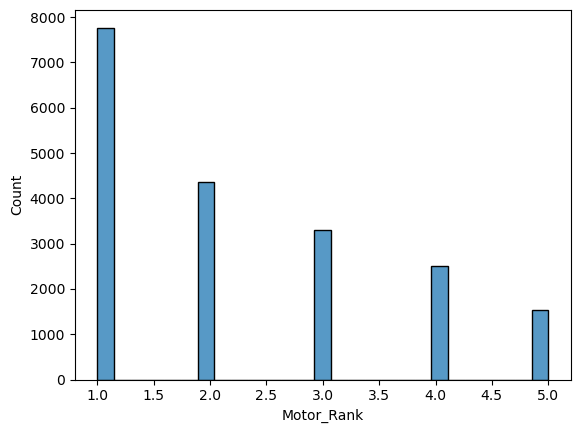

In [90]:
sns.histplot(rank_df,x='Motor_Rank')

<Axes: xlabel='Cognitive_Rank', ylabel='Count'>

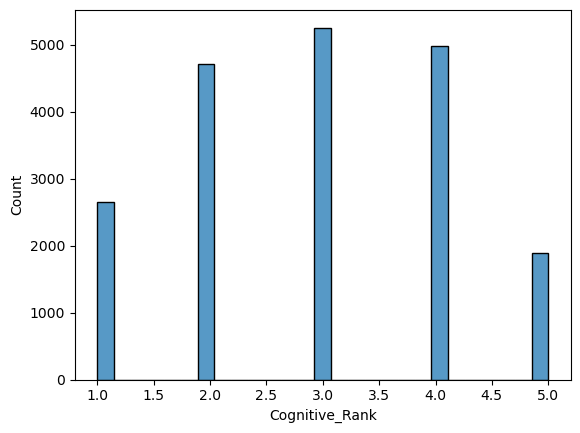

In [91]:
sns.histplot(rank_df,x='Cognitive_Rank')

In [92]:
domPR_df.corr()

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
Adaptive,1.000000,0.553170,0.463023,0.488734,0.471975
Social-Emotional,0.553170,1.000000,0.517923,0.458557,0.592173
Communication,0.463023,0.517923,1.000000,0.401353,0.650719
Motor,0.488734,0.458557,0.401353,1.000000,0.521958
Cognitive,0.471975,0.592173,0.650719,0.521958,1.000000


In [28]:
domPR_df

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
0,16.0,96.0,27.0,21.0,50.0
1,21.0,61.0,42.0,55.0,50.0
2,25.0,27.0,12.0,73.0,13.0
3,84.0,58.0,21.0,27.0,81.0
4,5.0,4.0,2.0,4.0,42.0
...,...,...,...,...,...
23942,84.0,84.0,79.0,88.0,81.0
23943,84.0,86.0,79.0,87.0,93.0
23944,58.0,55.0,0.1,61.0,45.0
23945,21.0,25.0,5.0,50.0,21.0


### 3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain? For example, a gap between a child's expressive (talking) and receptive (understanding) language scores may indicate that additional evaluation is needed for that child's eligibility. A gap between these sub-domains for all or most children may indicate the BDI-3 tool may lack sensitivity in the language domain.

### 4. Does the child's age seem to impact their scoring?

### 5. Eligibility is currently based on domains. A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores. A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay. If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

### 6. Is there any difference in scoring noted based on evaluation type?

### 7. Is there any notable pattern of scoring by region? Note: TEIS contracts with three agencies for evaluations (one per grand region) as follows:  
* East TN, First TN and Southeast
* Greater Nashville, Upper Cumberland, and South Central
* Northwest, Southwest, and Memphis Delta

### 8. Is there any notable pattern of scoring by evaluator?

### Stretch Goal:
* Investigate the records that are missing ID values. Have they gotten better or worse over time? Are there repeat offenders?
* As noted above, this evaluation may be repeated every 4 months. How often did it occur that a child was assessed multiple times in a time period of less than 120 days. Has this gotten better or worse over time?